In [ ]:
library(tidyr)
library(dplyr)
df <- read.csv("roubos.csv")
colnames(df) <- iconv(colnames(df), from = "UTF-8", to = "ASCII//TRANSLIT")

In [ ]:
df %>% group_by(ANO) %>% summarise(MEDIA = mean(ROUBOS, na.rm = TRUE))

ANO,MEDIA
<int>,<dbl>
2001,115.31481
2002,117.09259
2003,139.56481
2004,139.88889
2005,136.17593
2006,139.46296
2007,135.59259
2008,112.64815
2009,145.93519


In [ ]:
df %>% group_by(ANO) %>% summarise(MEDIANA = median(ROUBOS, na.rm = TRUE))

ANO,MEDIANA
<int>,<dbl>
2001,51.5
2002,63.0
2003,54.0
2004,55.5
2005,64.0
2006,61.0
2007,62.5
2008,49.0
2009,72.5


In [ ]:
df %>%
  group_by(ANO) %>%
  summarise(
    MODA = as.numeric(
      names(which.max(table(ROUBOS)))
    )
  )

ANO,MODA
<int>,<dbl>
2001,36
2002,12
2003,22
2004,45
2005,23
2006,59
2007,28
2008,21
2009,50


In [ ]:
df %>% group_by(ANO) %>% reframe(DESVIO = ROUBOS - mean(ROUBOS, na.rm = TRUE))

ANO,DESVIO
<int>,<dbl>
2001,-102.31481
2001,-103.31481
2001,-108.31481
2001,-109.31481
2001,-106.31481
2001,-109.31481
2001,-103.31481
2001,-104.31481
2001,-98.31481


In [ ]:
df %>% group_by(ANO) %>% summarise(DESVIO_PADRAO = sd(ROUBOS))

ANO,DESVIO_PADRAO
<int>,<dbl>
2001,97.68954
2002,119.12724
2003,136.24156
2004,134.21550
2005,124.40669
2006,127.17031
2007,121.63705
2008,110.24597
2009,121.93044


In [ ]:
df %>% group_by(ANO) %>% summarise(VARIANCIA = var(ROUBOS))

ANO,VARIANCIA
<int>,<dbl>
2001,9543.246
2002,14191.300
2003,18561.762
2004,18013.801
2005,15477.025
2006,16172.288
2007,14795.571
2008,12154.174
2009,14867.033


In [ ]:
df %>% group_by(ANO) %>% summarise(DESVIO_ABS_MEDIO = mean(abs(ROUBOS - mean(ROUBOS))))

ANO,DESVIO_ABS_MEDIO
<int>,<dbl>
2001,92.25720
2002,93.28978
2003,119.37877
2004,117.13169
2005,109.88066
2006,110.74520
2007,108.44719
2008,96.23011
2009,112.46502


In [ ]:
df %>% group_by(ANO) %>% summarise(MAD = mad(ROUBOS))

ANO,MAD
<int>,<dbl>
2001,62.2692
2002,77.0952
2003,65.2344
2004,60.0453
2005,66.7170
2006,63.0105
2007,63.7518
2008,49.6671
2009,74.1300


In [ ]:
df %>% group_by(ANO) %>% summarise(AMPLITUDE = diff(range(ROUBOS)))

ANO,AMPLITUDE
<int>,<int>
2001,323
2002,655
2003,478
2004,534
2005,483
2006,496
2007,424
2008,439
2009,427


In [ ]:
df %>% group_by(ANO) %>% summarise(QUANTIL = quantile(ROUBOS, probs = 0.9))

ANO,QUANTIL
<int>,<dbl>
2001,254.6
2002,256.7
2003,349.1
2004,356.3
2005,319.0
2006,323.3
2007,330.0
2008,284.3
2009,326.6



    Bertioga      Cubatão      Guarujá     Itanhaém     Mongaguá      Peruíbe 
   0.1111111    0.1111111    0.1111111    0.1111111    0.1111111    0.1111111 
Praia Grande       Santos  São Vicente 
   0.1111111    0.1111111    0.1111111 

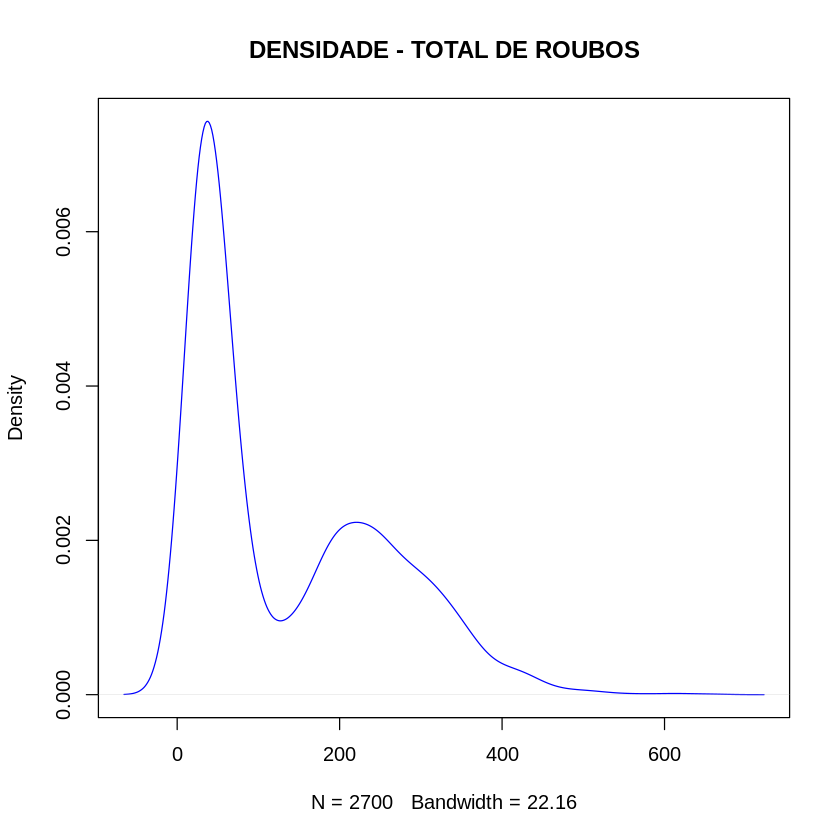

In [ ]:
plot(density(df$ROUBOS), main = "DENSIDADE - TOTAL DE ROUBOS", col = "blue")

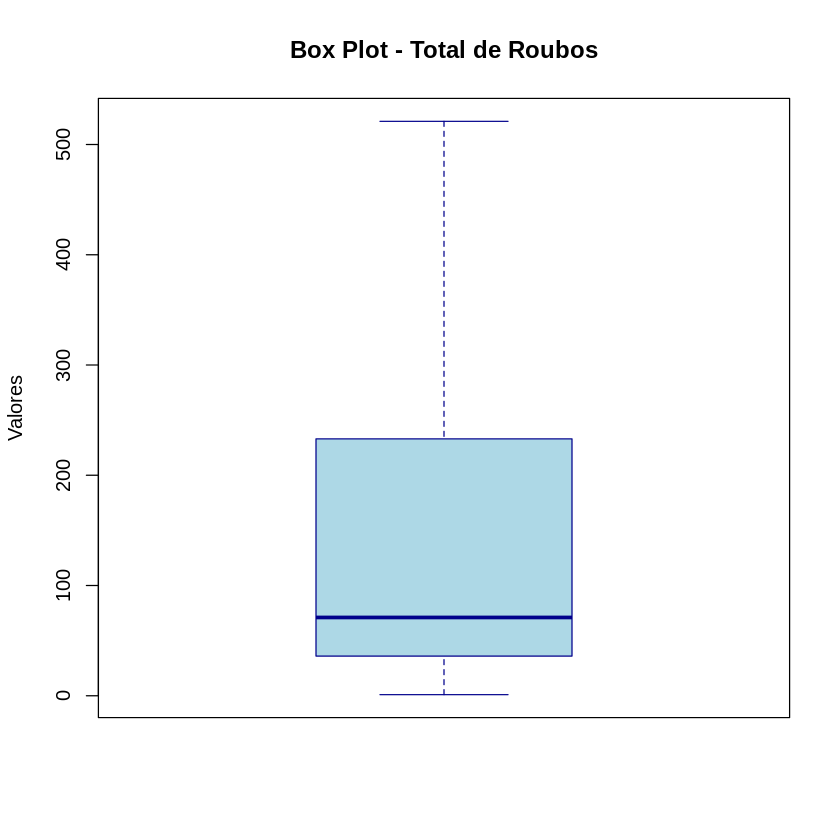

In [ ]:
boxplot(df$ROUBOS,
main = "Box Plot - Total de Roubos",
ylab = "Valores",
col = "lightblue",
border = "darkblue",
outline = FALSE,
notch = F)

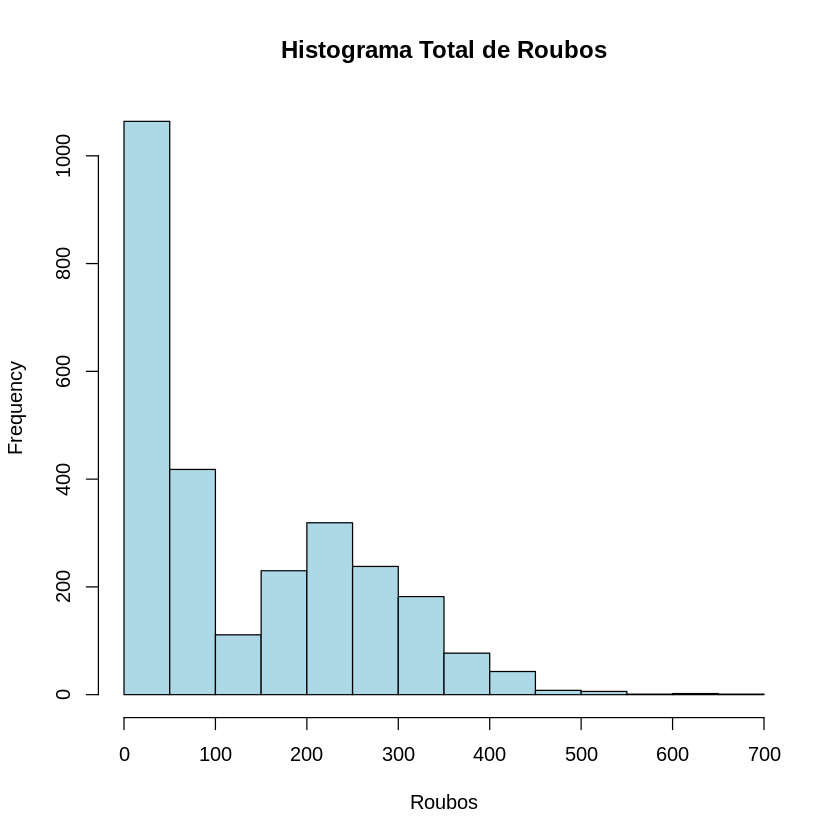

In [ ]:
roubos <- df$ROUBOS

hist(roubos,
     col = "lightblue",
     main = "Histograma Total de Roubos",
     xlab = "Roubos")

In [ ]:
install.packages("fitdistrplus")
library(fitdistrplus)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: MASS


Attaching package: ‘MASS’


The following object is masked from ‘package:dplyr’:

    select


Loading required package: survival



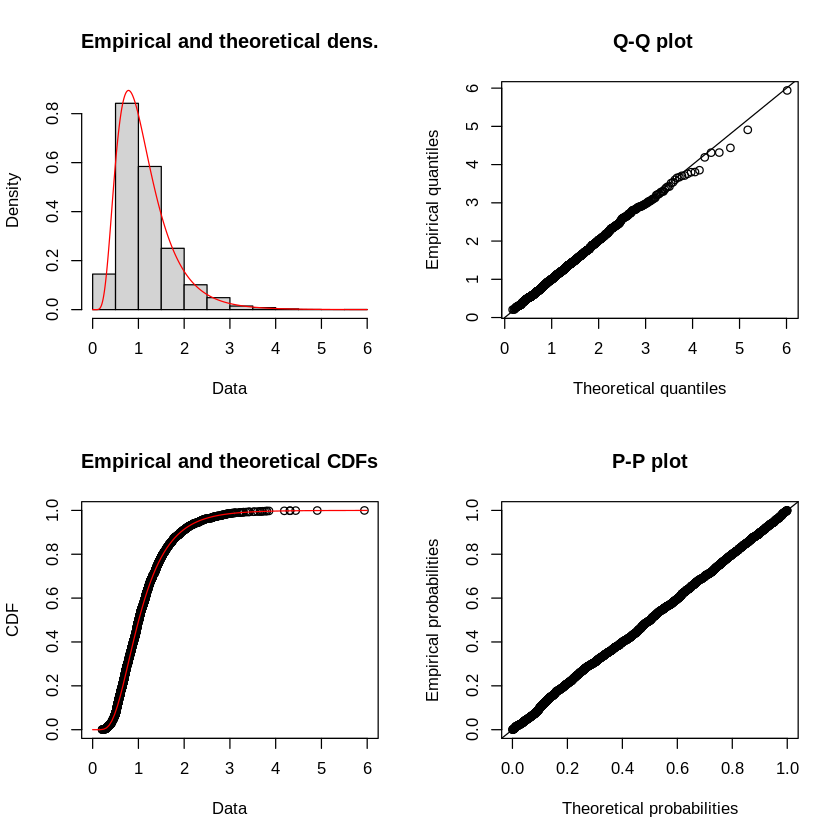

In [ ]:
x <- rlnorm(df$ROUBOS, meanlog = 0, sdlog = 0.5)
ajuste <- fitdist(x, "lnorm")
plot(ajuste)

mean 
9.795552

Fitting of the distribution ' norm ' by maximum likelihood 
Parameters : 
     estimate Std. Error
mean 9.795552  0.2134073
sd   3.018034  0.1509016
Loglikelihood:  -504.7089   AIC:  1013.418   BIC:  1020.014 
Correlation matrix:
     mean sd
mean    1  0
sd      0  1


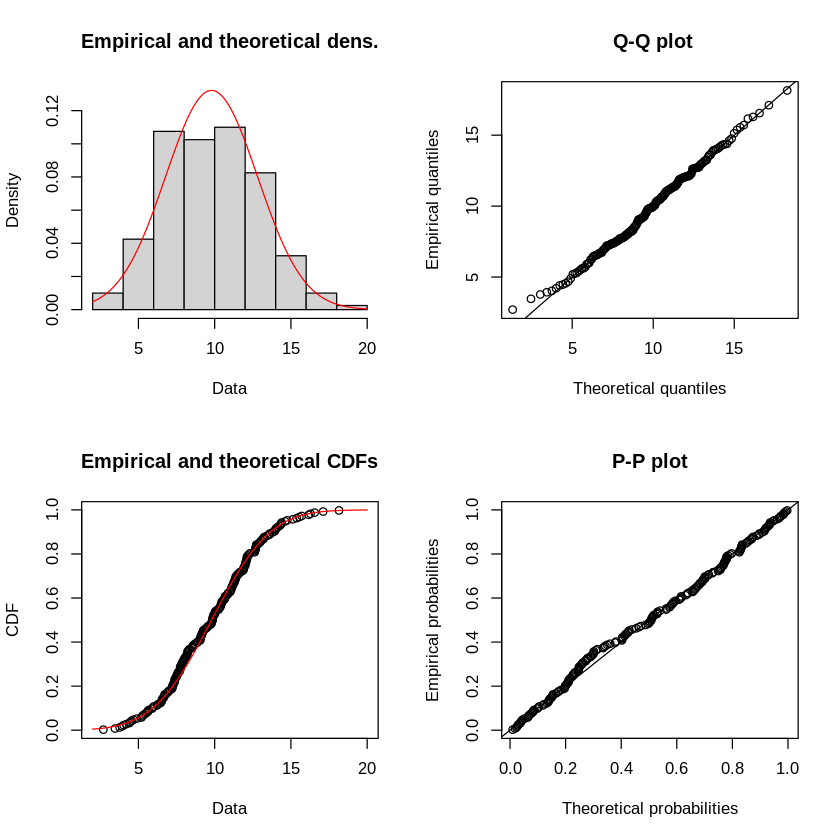

In [ ]:
x <- rnorm(200, mean = 10, sd = 3)

ajuste_norm <- fitdist(x, "norm")

ajuste_norm$estimate[1]

summary(ajuste_norm)

plot(ajuste_norm)

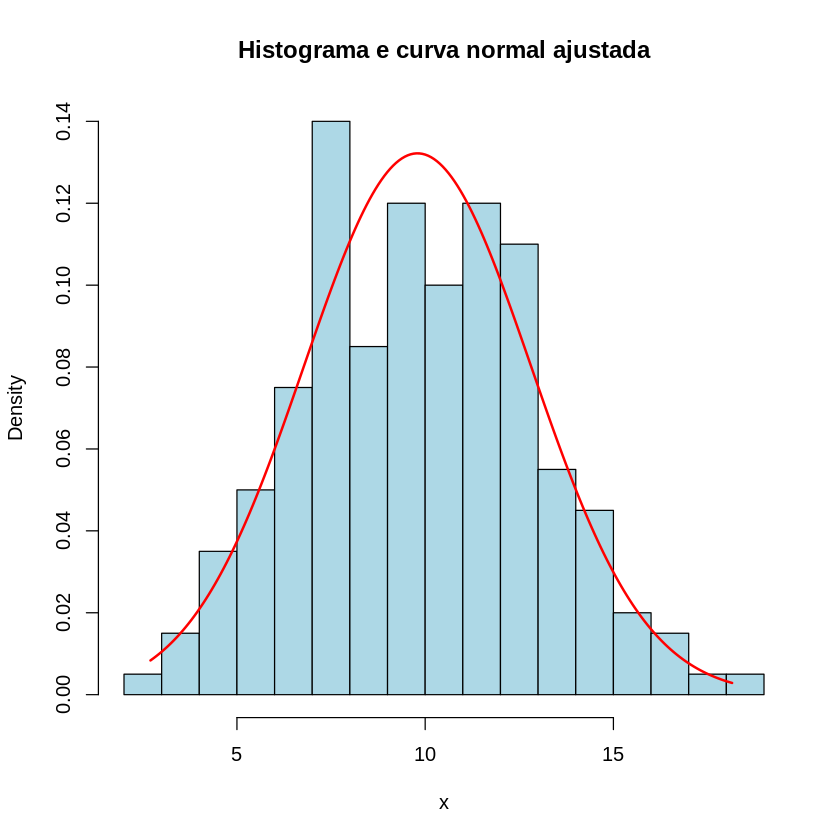

In [ ]:
hist(x, breaks = 20, probability = TRUE, col = "lightblue",
     main = "Histograma e curva normal ajustada", xlab = "x")

# Sequência de pontos no eixo x
x_seq <- seq(min(x), max(x), length.out = 200)

# Curva da densidade normal ajustada
lines(x_seq, dnorm(x_seq, mean = ajuste_norm$estimate["mean"],
                         sd   = ajuste_norm$estimate["sd"]),
      col = "red", lwd = 2)

Fitting of the distribution ' chisq ' by maximum likelihood 
Parameters : 
   estimate Std. Error
df 4.974377 0.05479582
Loglikelihood:  -6441.089   AIC:  12884.18   BIC:  12890.08 

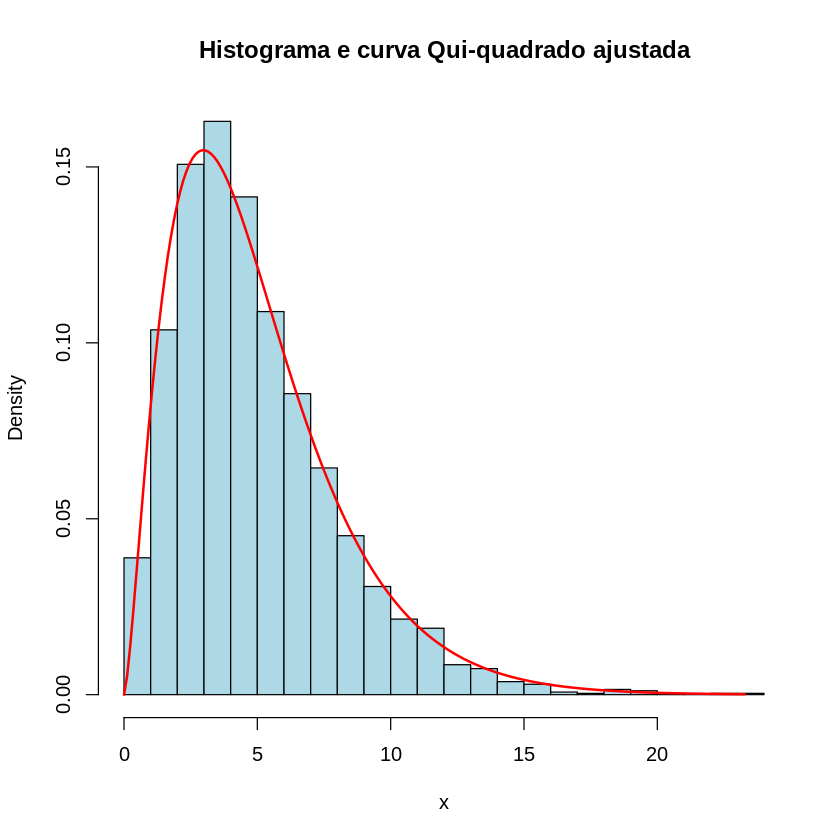

In [ ]:
set.seed(123)
# Simulando 200 dados de uma qui-quadrado com df = 5
x <- rchisq(df$ROUBOS, df = 5)

# Ajuste da distribuição qui-quadrado
# start = lista com valor inicial para df
ajuste_chi <- fitdist(x, "chisq", start = list(df = 5))

# Resumo do ajuste
summary(ajuste_chi)

# Histograma em escala de densidade
hist(x, breaks = 20, probability = TRUE, col = "lightblue",
     main = "Histograma e curva Qui-quadrado ajustada", xlab = "x")

# Sequência de pontos no eixo x
x_seq <- seq(0, max(x), length.out = 200)

# Curva da densidade qui-quadrado ajustada
lines(x_seq, dchisq(x_seq, df = ajuste_chi$estimate["df"]),
      col = "red", lwd = 2)